# 14 &middot; Bending Stiffness: a Mass-Spring Beam that Resists Bending

Tutorial 11 built a mass-spring **cable**: springs only resist *stretch*, so a cable clamped at one
end just flops down. Here we add a **bending** energy on the hinge turning angles, clamp one end (a
cantilever), and watch the beam go from floppy to rigid as the bending stiffness $EI$ grows. Then we
refine the mesh and check that the equilibrium converges to a single shape.

Imports, and every tunable parameter of this notebook.

In [1]:
%matplotlib inline
import os
import numpy as np
import scipy as sp
import matplotlib.pyplot as plt
import simkit
import utils

NOTEBOOK = "014_bending_stiffness"                                 # this file's name
RESULTS_DIR = utils.notebook_results_path(NOTEBOOK)                # results/014_bending_stiffness/
MEDIA_DIR = "media"                                                # tracked copies for the website
# continuum beam and load (fixed: only the discretization N changes)
L = 4.0              # beam length
EA = 2.0e4           # axial (stretch) stiffness, EA >> EI so the beam is nearly inextensible
RHO = 0.2            # mass per unit length
G = -9.8             # gravitational acceleration (y)
# discretization and clamp
N = 21               # nodes of the default beam
N_CLAMP = 2          # leftmost nodes pinned: fixes the root position AND tangent
K_PIN = 1e10         # clamp penalty stiffness
EI_DEFAULT = 50.0    # bending stiffness of the default beam
STATIC_ITERS = 200   # Newton iterations for a static equilibrium
FD_STEP = 1e-4       # central-difference step for the gradient check
FD_NOISE = 0.05      # size of the random perturbation for the gradient check
SEED = 0             # random seed for the gradient check
# section 2: bending energy of an arc
MAX_TURN = 2.5       # largest total turning angle (rad)
N_TURNS = 60         # samples of the turning angle
ARC_TURNS = [0.5, 1.5, 2.5]   # arcs drawn next to the energy curve
# dynamics (sections 1 and 3)
DT = 0.02            # backward-Euler time step
N_STEPS = 160        # time steps per simulation
N_FRAMES = 60        # frames sampled for the videos
STEP_ITERS = 20      # Newton iterations per time step
FPS = 20             # video frame rate
EI_DYNAMIC = {"soft": 2.0, "medium": 50.0, "stiff": 2000.0}   # released under gravity
# section 3: static sweep, section 4: mesh refinement
EI_STATIC = [2.0, 20.0, 200.0, 2000.0]   # static equilibria at these stiffnesses
N_REFINE = [5, 9, 17, 33, 65]            # node counts for the refinement study
N_REFERENCE = 129                        # finest mesh, used as the reference solution

## The cantilever beam

The beam is a horizontal chain of nodes. Consecutive nodes are joined by **springs** (`E`, stretch), and
every interior node carries a **hinge** triple `C = (i, i+1, i+2)` that measures the turning angle
between its two segments (bend). We clamp the root by pinning the `N_CLAMP = 2` leftmost nodes: two
fixed nodes fix both the position *and* the tangent of the built-in end, which makes it a cantilever
rather than a free pivot. `simkit.uniform_line` gives the nodes and springs, and consecutive springs give
the hinges.

In [2]:
def beam_mesh(n_nodes):
    """Straight beam of length L on the x-axis: nodes X, springs E, hinge triples C."""
    s, E = simkit.uniform_line(n_nodes, return_simplex=True)     # s in [0, 1], E = (k, k+1)
    X = np.hstack([L * s, np.zeros_like(s)])
    C = np.stack([E[:-1, 0], E[:-1, 1], E[1:, 1]], axis=1)       # two consecutive springs = one hinge
    return X, E, C


X, E, C = beam_mesh(N)
pin_idx = np.arange(N_CLAMP)
print(f"default beam: {len(X)} nodes, {len(E)} springs, {len(C)} hinges, pinned nodes {pin_idx}")

default beam: 21 nodes, 20 springs, 19 hinges, pinned nodes [0 1]


Every beam used below, at rest, with nodes colored by their lumped mass (`simkit.massmatrix` on the
springs). The mass per node shrinks as `N` grows, but the total mass $\rho L$ stays fixed, one
ingredient of a mesh-independent discretization.

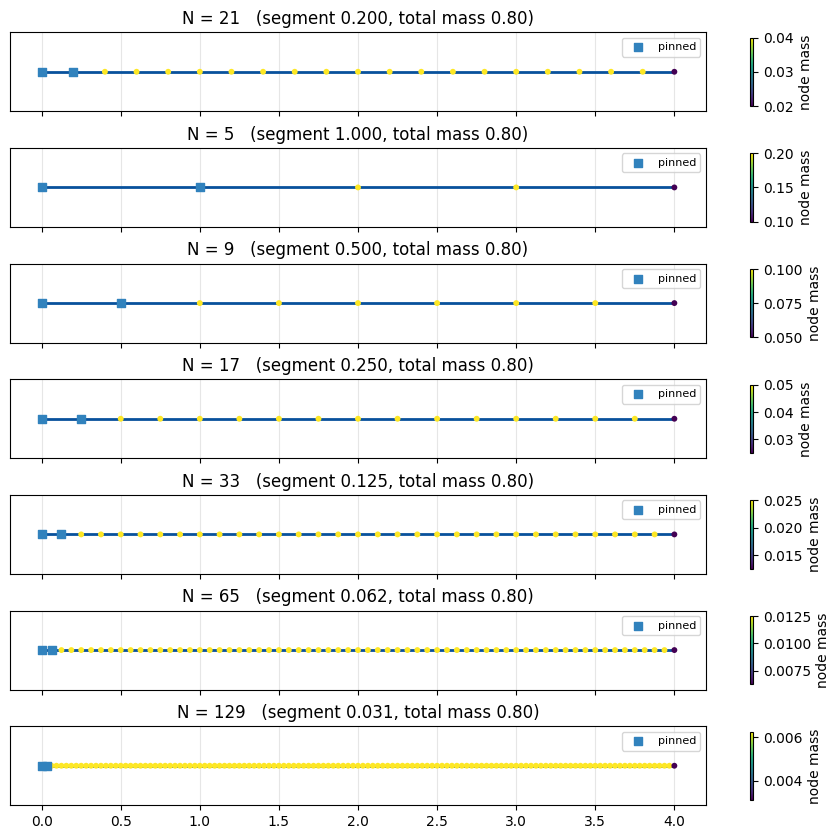

In [3]:
meshes = [N] + N_REFINE + [N_REFERENCE]
fig, axes = plt.subplots(len(meshes), 1, figsize=(9, 1.2 * len(meshes)), sharex=True)
for ax, n_nodes in zip(axes, meshes):
    Xn, En, _ = beam_mesh(n_nodes)
    m = simkit.massmatrix(Xn, En, rho=RHO).diagonal()
    utils.plot_spring_network(ax, Xn, En, node_values=m, pins=pin_idx, lims=((-0.2, L + 0.2), (-0.25, 0.25)),
                              node_size=18, label="node mass",
                              title=f"N = {n_nodes}   (segment {L / (n_nodes - 1):.3f}, total mass {m.sum():.2f})")
    ax.set_yticks([])
fig.tight_layout()
simkit.filesystem.save_figure(fig, os.path.join(RESULTS_DIR, "beam_meshes.png"),
                              copy_to=os.path.join(MEDIA_DIR, "014_beam_meshes.png"))
plt.show()

## The potential

With flattened node positions $x$, the static potential is a stretch term per spring $e$, a bending term
per hinge $i$ (turning angle $\theta_i$ from `simkit.dihedral_angles`, rest angle $\theta_i^0 = 0$), gravity
and the clamp penalty. The coefficients discretize a fixed continuum beam, so refining the mesh converges:
$\tfrac12 EA\!\int\!\varepsilon^2 ds$ becomes a spring with stiffness $EA/\ell_e$ (simkit density
$\tfrac12 k(\|d_e\|-\ell_e)^2$ with $k = EA/\ell_e^2$ and quadrature weight $\ell_e$), $\tfrac12 EI\!\int\!k^2 ds$
(continuum curvature $k$) becomes a hinge stiffness $\kappa_i = EI/\ell_i$ since $\theta_i \approx k\,\ell_i$, with
$\ell_i$ the mean length of the hinge's two springs (`simkit.joint_lengths`), and the lumped mass spreads the
fixed total $\rho L$ over the nodes.

$$
\Phi(x) = \sum_e \tfrac12\,\tfrac{EA}{\ell_e}\big(\|d_e(x)\|-\ell_e\big)^2
        + \sum_i \tfrac12\,\tfrac{EI}{\ell_i}\big(\theta_i(x)-\theta_i^0\big)^2
        - f_g^\top x + \tfrac12 x^\top Q x + b^\top x
$$

In [4]:
def cantilever_system(X, E, C, EI, pin_idx, psd=True):
    """Static potential of the clamped beam: springs + hinge bending + gravity + clamp.
    psd=True projects each hinge Hessian block to PSD (always a descent direction)."""
    n, dim = X.shape
    l0 = simkit.edge_lengths(X, E).reshape(-1, 1)             # rest spring lengths l_e
    ym = EA / l0 ** 2                                         # spring stiffness -> EA / l_e per spring
    vol = l0                                                  # quadrature weight of each spring
    l_hinge = simkit.joint_lengths(X, C).reshape(-1, 1)       # length l_i attached to each hinge
    kappa = EI / l_hinge                                      # hinge stiffness EI / l_i
    theta0 = simkit.dihedral_angles(X, C)                     # rest turning angles (0: straight beam)
    f_g = simkit.gravity_force(X, E, a=G, rho=RHO).reshape(-1, 1)
    Q_pin, b_pin = simkit.dirichlet_penalty(pin_idx, X[pin_idx], n, K_PIN)

    def energy_func(x):
        E_stretch = simkit.energies.mass_springs_energy_x(x.reshape(n, dim), E, ym, vol, l0)
        E_bend = simkit.energies.bending_energy_x(x, C, theta0, kappa)
        E_gravity = -(f_g.T @ x).item()
        E_pin = simkit.energies.quadratic_energy(x, Q_pin, b_pin)
        E_total = E_stretch + E_bend + E_gravity + E_pin
        return E_total

    def gradient_func(x):
        g_stretch = simkit.energies.mass_springs_gradient_x(x.reshape(n, dim), E, ym, vol, l0)
        g_bend = simkit.energies.bending_gradient_x(x, C, theta0, kappa)
        g_gravity = -f_g
        g_pin = simkit.energies.quadratic_gradient(x, Q_pin, b_pin)
        g_total = g_stretch + g_bend + g_gravity + g_pin
        return g_total

    def hessian_func(x):
        H_stretch = simkit.energies.mass_springs_hessian_x(x.reshape(n, dim), E, ym, vol, l0, psd=True)
        H_bend = simkit.energies.bending_hessian_x(x, C, theta0, kappa, psd=psd)
        H_pin = simkit.energies.quadratic_hessian(Q_pin)
        H_total = H_stretch + H_bend + H_pin
        return H_total

    return energy_func, gradient_func, hessian_func

`solve_static` minimizes $\Phi$ with Newton from the flat rest shape. On the default beam we first check the
analytic gradient against central differences (`simkit.gradient_cfd`) at a randomly bent state (the clamped
nodes stay put, so the check sees springs, hinges and gravity), then solve, once with the PSD-projected hinge
Hessian used throughout the notebook and once with the exact one. The gradient error is tiny, both solves
reach the same tip, and the stretch strain is negligible next to the bending deflection.

In [5]:
def solve_static(EI, n_nodes=N, psd=True):
    """Static equilibrium of the n_nodes cantilever: nodes (n, 2) and Newton's per-iteration info."""
    Xn, En, Cn = beam_mesh(n_nodes)
    energy_func, gradient_func, hessian_func = cantilever_system(Xn, En, Cn, EI, pin_idx, psd=psd)
    x, info = simkit.solvers.newton_solver(Xn.reshape(-1, 1), energy_func, gradient_func, hessian_func,
                                           max_iter=STATIC_ITERS, do_line_search=True, return_info=True)
    return x.reshape(n_nodes, 2), info


energy_func, gradient_func, hessian_func = cantilever_system(X, E, C, EI_DEFAULT, pin_idx)
noise = FD_NOISE * np.random.default_rng(SEED).standard_normal(X.shape)
noise[pin_idx] = 0.0
x_test = (X + noise).reshape(-1, 1)
g_fd = simkit.gradient_cfd(lambda y: np.array(energy_func(y)), x_test, FD_STEP)
g_an = gradient_func(x_test).ravel()
print(f"gradient check: |g_fd - g| / |g| = {np.linalg.norm(g_fd - g_an) / np.linalg.norm(g_an):.1e}")

U_default, info_default = solve_static(EI_DEFAULT)
U_exact, info_exact = solve_static(EI_DEFAULT, psd=False)
strain = simkit.edge_lengths(U_default, E) / simkit.edge_lengths(X, E) - 1.0
for name, U, info in [("PSD hinge Hessian", U_default, info_default), ("exact hinge Hessian", U_exact, info_exact)]:
    print(f"{name:>19}: {info['iters'] + 1:3d} Newton iterations, "
          f"|grad| = {np.linalg.norm(gradient_func(U.reshape(-1, 1))):.1e}, tip = {np.round(U[-1], 3)}")
print(f"max stretch strain = {strain.max():.1e}")

gradient check: |g_fd - g| / |g| = 6.7e-08
  PSD hinge Hessian:  35 Newton iterations, |grad| = 2.9e-05, tip = [ 3.83  -1.064]
exact hinge Hessian:  13 Newton iterations, |grad| = 5.0e-06, tip = [ 3.83  -1.064]
max stretch strain = 6.6e-05


Four checks of that equilibrium. **Top left:** the beam colored by its discrete curvature $\theta_i/\ell_i$,
largest in magnitude at the clamp (negative: the beam turns clockwise) and near zero at the free tip.
**Top right:** the stretch strain of every spring, a tension below $10^{-4}$ (far smaller than the bending deflection)
that peaks mid-span, where the sloped tangent carries part of the overhang's weight. **Bottom left:** the moment each hinge carries,
$\kappa_i\theta_i$, against the gravity moment of the overhang beyond it, $\sum_{j>i} f_{g,j}\,(x_j - x_i)$;
torque balance says they must agree, and the printed maximum mismatch (~1e-4 against moments up to ~14) is the
Newton residual. **Bottom right:** Newton's gradient norm per iteration. It first jumps and oscillates while the
line-searched steps swing the beam down from flat; then the exact hinge Hessian converges quadratically, while the
PSD projection (which drops the negative part of the geometric term $\kappa_i\theta_i\,\partial^2\theta_i/\partial x^2$)
converges only linearly, the price of a guaranteed descent direction.

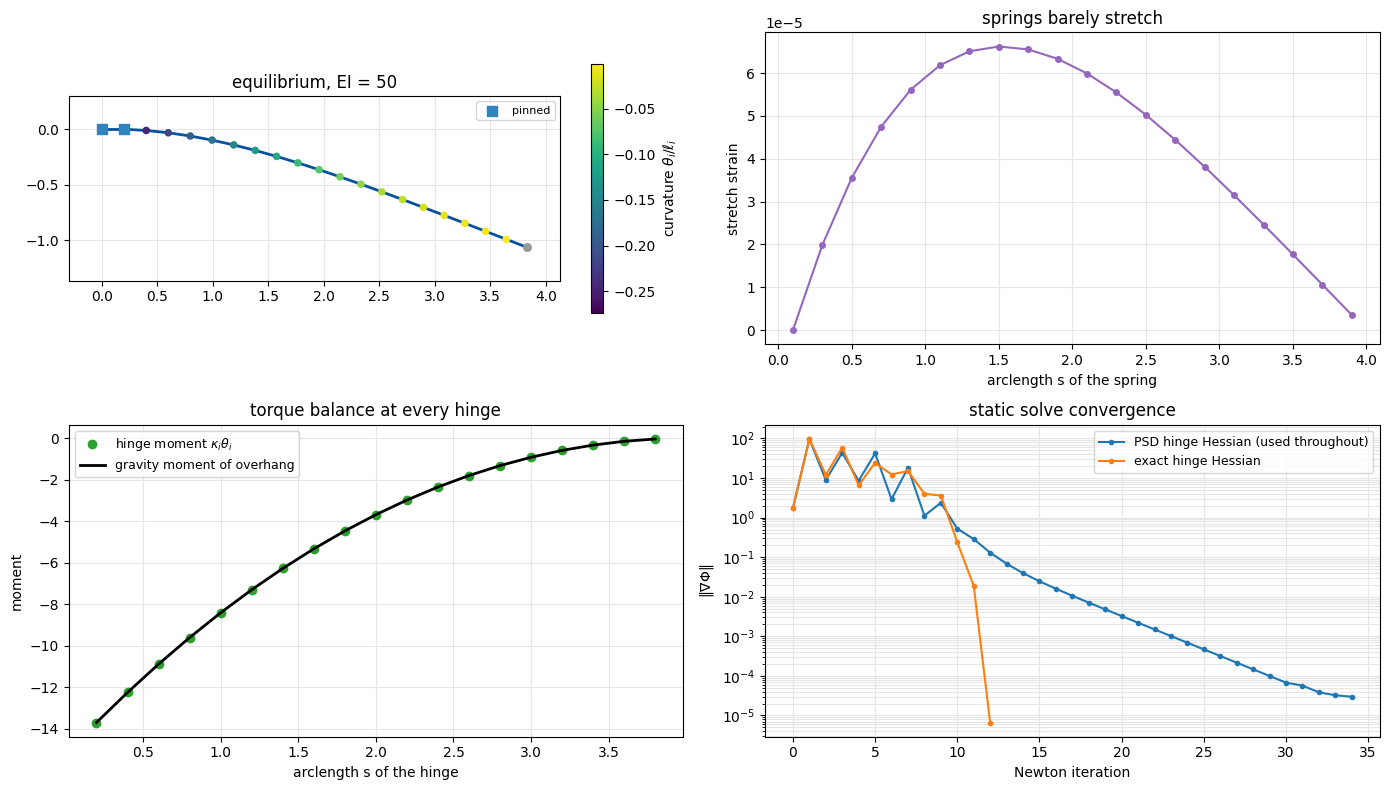

max |hinge moment - gravity moment| = 1.0e-04


In [6]:
theta = simkit.dihedral_angles(U_default, C).ravel()
l_hinge = simkit.joint_lengths(X, C)
curvature = np.full(N, np.nan)
curvature[C[:, 1]] = theta / l_hinge
f_g = simkit.gravity_force(X, E, a=G, rho=RHO)
hinge_moment = EI_DEFAULT / l_hinge * theta
gravity_moment = np.array([np.sum(f_g[i + 1:, 1] * (U_default[i + 1:, 0] - U_default[i, 0])) for i in C[:, 1]])

fig, ((ax_beam, ax_strain), (ax_torque, ax_newton)) = plt.subplots(2, 2, figsize=(14, 8))
utils.plot_spring_network(ax_beam, U_default, E, node_values=curvature, pins=pin_idx, cmap="viridis",
                          lims=utils.auto_limits([U_default], pad=0.3), label=r"curvature $\theta_i/\ell_i$",
                          title=f"equilibrium, EI = {EI_DEFAULT:g}")
s_spring = X[E, 0].mean(axis=1)                               # rest arclength of each spring's midpoint
ax_strain.plot(s_spring, strain, "o-", ms=4, color="#9467bd")
ax_strain.set(xlabel="arclength s of the spring", ylabel="stretch strain", title="springs barely stretch")
ax_strain.grid(True, color="0.9")
s_hinge = X[C[:, 1], 0]
ax_torque.plot(s_hinge, hinge_moment, "o", ms=6, color=utils.ENERGY_COLORS["elastic"], label=r"hinge moment $\kappa_i\theta_i$")
ax_torque.plot(s_hinge, gravity_moment, "-", lw=2, color="k", label="gravity moment of overhang")
ax_torque.set(xlabel="arclength s of the hinge", ylabel="moment", title="torque balance at every hinge")
ax_torque.grid(True, color="0.9"); ax_torque.legend(fontsize=9)
for info, name, color in [(info_default, "PSD hinge Hessian (used throughout)", utils.SOLVER_COLORS["Newton"]),
                          (info_exact, "exact hinge Hessian", "#ff7f0e")]:
    grad_norms = [np.linalg.norm(g) for g in info["g"]]
    ax_newton.semilogy(np.arange(len(grad_norms)), grad_norms, "-o", ms=3, color=color, label=name)
ax_newton.legend(fontsize=9)
ax_newton.set(xlabel="Newton iteration", ylabel=r"$\|\nabla\Phi\|$", title="static solve convergence")
ax_newton.grid(True, which="both", color="0.9")
fig.tight_layout()
simkit.filesystem.save_figure(fig, os.path.join(RESULTS_DIR, "static_validation.png"),
                              copy_to=os.path.join(MEDIA_DIR, "014_static_validation.png"))
plt.show()
print(f"max |hinge moment - gravity moment| = {np.abs(hinge_moment - gravity_moment).max():.1e}")

## 1 &middot; Springs alone can't hold a shape

For dynamics each backward-Euler step minimizes the inertia term plus the static potential,
$\tfrac{1}{2h^2}\|x - (2x_t - x_{t-1})\|_M^2 + \Phi(x)$. `backward_euler_system` wraps the cantilever
potential with `simkit.energies.kinetic_*_be`, and `simulate` rebuilds it at every step with the two latest
states, releasing the beam from flat and recording frames, kinetic energy and the tip height.

In [7]:
def backward_euler_system(potential, M, x_curr, x_prev, h):
    """One backward-Euler step as a minimization: inertia + the static potential."""
    energy_potential, gradient_potential, hessian_potential = potential

    def energy_func(x):
        E_inertia = simkit.energies.kinetic_energy_be(x, x_curr, x_prev, M, h)
        E_potential = energy_potential(x)
        E_total = E_inertia + E_potential
        return E_total

    def gradient_func(x):
        g_inertia = simkit.energies.kinetic_gradient_be(x, x_curr, x_prev, M, h)
        g_potential = gradient_potential(x)
        g_total = g_inertia + g_potential
        return g_total

    def hessian_func(x):
        H_inertia = simkit.energies.kinetic_hessian_be(M, h)
        H_potential = hessian_potential(x)
        H_total = H_inertia + H_potential
        return H_total

    return energy_func, gradient_func, hessian_func


def simulate(EI, n_nodes=N):
    """Release the flat cantilever under gravity; return sampled frames, their times and kinetic
    energies, plus the tip height at every step."""
    Xn, En, Cn = beam_mesh(n_nodes)
    potential = cantilever_system(Xn, En, Cn, EI, pin_idx)
    M = sp.sparse.kron(simkit.massmatrix(Xn, En, rho=RHO), sp.sparse.eye(2)).tocsc()
    x_prev = Xn.reshape(-1, 1).copy()
    x_curr = x_prev.copy()
    sample = set(np.linspace(0, N_STEPS, N_FRAMES).astype(int))
    frames, times, kinetic, tip_y = [Xn.copy()], [0.0], [0.0], [0.0]
    for step in range(1, N_STEPS + 1):
        step_funcs = backward_euler_system(potential, M, x_curr, x_prev, DT)
        x_next = simkit.solvers.newton_solver(x_curr.copy(), *step_funcs, max_iter=STEP_ITERS, do_line_search=True)
        x_prev, x_curr = x_curr, x_next
        tip_y.append(x_curr[-1, 0])
        if step in sample:
            v = (x_curr - x_prev) / DT
            frames.append(x_curr.reshape(n_nodes, 2).copy())
            times.append(step * DT)
            kinetic.append(0.5 * (v.T @ M @ v).item())
    return frames, np.array(times), np.array(kinetic), np.array(tip_y)

Turn bending **off** (`EI = 0`) and release the clamped chain (the view is fitted to every frame). With no
resistance to curvature the chain swings down past vertical like a pendulum and back, exactly the cable behavior
of tutorial 11; the kinetic energy (right) rises and falls with every swing, damped only slowly by backward Euler.

In [8]:
frames, times, kinetic, _ = simulate(0.0)
x_lims, (y_lo, y_hi) = utils.auto_limits(frames)                    # fit every frame ...
fig, anim = utils.animate_springs_energy(
    frames, E, times, {"kinetic": kinetic}, rest=X, lims=(x_lims, (y_lo, y_hi + 0.8)),   # ... plus room for the legend
    xlabel="time (s)", ylabel="kinetic energy", scene_title="springs only (EI = 0): it swings like a chain",
    title="kinetic energy", colors={"kinetic": utils.ENERGY_COLORS["kinetic"]}, pin_pts=X[pin_idx])
video = simkit.filesystem.save_animation(anim, os.path.join(RESULTS_DIR, "springs_only.mp4"), fps=FPS,
                                         copy_to=os.path.join(MEDIA_DIR, "014_springs_only.mp4"))
plt.close(fig)
utils.embed_video(video)

## 2 &middot; Bending energy penalizes the turning angle

The bending energy sums $\tfrac12\kappa_i(\theta_i-\theta_i^0)^2$ over hinges, so it grows quadratically as we
curl the beam into a circular arc of total turning angle $\Theta$ (`utils.arc_polyline` gives every hinge the same
angle $\Theta/(N-1)$). **Left:** three arcs colored by their hinge angle, stacked top to bottom. **Right:** the
energy follows the continuum value $EI\,\Theta^2/2L$ (dashed) up to the factor $(N-2)/(N-1)$, because the $N-1$
segments meet at only $N-2$ hinges, which confirms the $\kappa_i = EI/\ell_i$ scaling.

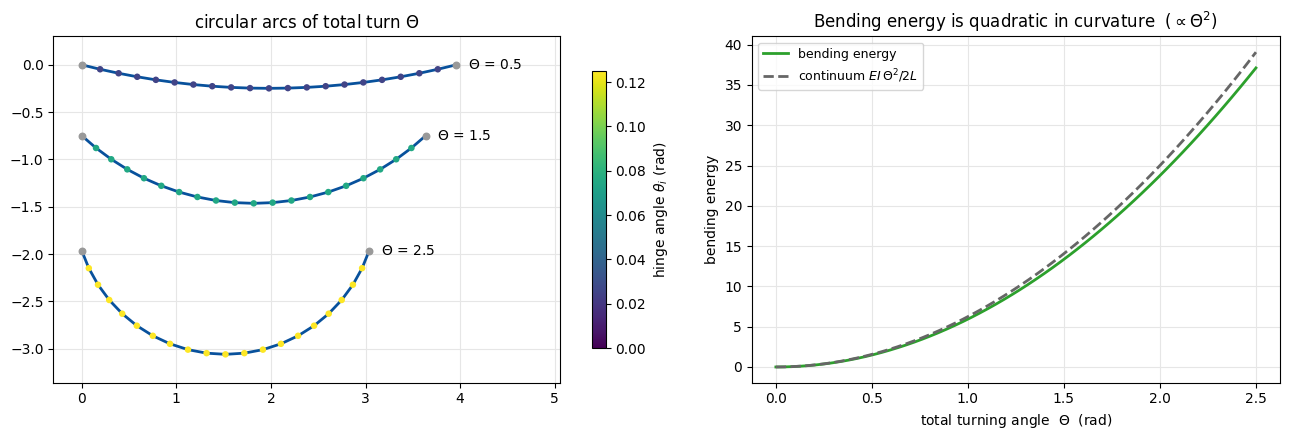

In [9]:
theta0 = simkit.dihedral_angles(X, C)
kappa = EI_DEFAULT / simkit.joint_lengths(X, C).reshape(-1, 1)
turns = np.linspace(0.0, MAX_TURN, N_TURNS)
E_arc = [simkit.energies.bending_energy_x(utils.arc_polyline(L, N, t).reshape(-1, 1), C, theta0, kappa) for t in turns]

arcs, dy = [], 0.0
for t in ARC_TURNS:                                                  # stack the arcs top to bottom
    arcs.append(utils.arc_polyline(L, N, t) + np.array([0.0, dy]))
    dy = arcs[-1][:, 1].min() - 0.5
(x_lo, x_hi), y_lims = utils.auto_limits(arcs, pad=0.3)
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5), gridspec_kw={"width_ratios": [1.2, 1]})
for j, (t, A) in enumerate(zip(ARC_TURNS, arcs)):
    hinge_angle = np.full(N, np.nan)
    hinge_angle[C[:, 1]] = simkit.dihedral_angles(A, C).ravel()
    utils.plot_spring_network(axes[0], A, E, node_values=hinge_angle, vmin=0.0, vmax=MAX_TURN / (N - 1),
                              cmap="viridis", node_size=22, colorbar=(j == 0), label=r"hinge angle $\theta_i$ (rad)",
                              lims=((x_lo, x_hi + 0.2 * L), y_lims), title=r"circular arcs of total turn $\Theta$")
    axes[0].text(A[-1, 0] + 0.12, A[-1, 1], rf"$\Theta$ = {t:g}", va="center", ha="left", fontsize=10)
utils.line_plot(turns, {"bending energy": E_arc, r"continuum $EI\,\Theta^2/2L$": EI_DEFAULT * turns ** 2 / (2 * L)},
                xlabel=r"total turning angle  $\Theta$  (rad)", ylabel="bending energy", ax=axes[1],
                colors={"bending energy": utils.ENERGY_COLORS["elastic"], r"continuum $EI\,\Theta^2/2L$": "0.4"},
                title=r"Bending energy is quadratic in curvature  ($\propto \Theta^2$)")
axes[1].lines[1].set_linestyle("--")
axes[1].legend(fontsize=9)
fig.tight_layout()
simkit.filesystem.save_figure(fig, os.path.join(RESULTS_DIR, "bending_energy.png"),
                              copy_to=os.path.join(MEDIA_DIR, "014_bending_energy.png"))
plt.show()

## 3 &middot; Flop when soft, hold its shape when stiff

Release the cantilever under gravity at three bending stiffnesses. The soft beam **flops around**, swinging
down past vertical and curling back; as $EI$ grows the beam **holds its shape**, barely deflecting from
horizontal. Stretching stays stiff throughout ($EA \gg EI$), so only the resistance to *bending* changes.

In [10]:
runs = {name: simulate(EI) for name, EI in EI_DYNAMIC.items()}
panels = [{"states": runs[name][0], "E": E, "title": f"{name}  (EI={EI:g})"} for name, EI in EI_DYNAMIC.items()]
all_frames = [U for run in runs.values() for U in run[0]]                 # fit the view to every frame of every run
fig, anim = utils.animate_springs_grid(panels, lims=utils.auto_limits(all_frames), fps=FPS, pin_pts=X[pin_idx],
                                       suptitle="Same beam, same gravity: stiffer bending = holds its shape")
video = simkit.filesystem.save_animation(anim, os.path.join(RESULTS_DIR, "flop_to_rigid.mp4"), fps=FPS,
                                         copy_to=os.path.join(MEDIA_DIR, "014_flop_to_rigid.mp4"))
plt.close(fig)
utils.embed_video(video)

The tip height over time for the same three runs, with each beam's static equilibrium (dashed); the right panel
zooms in on the stiffest beam, whose swing of a few hundredths is invisible at the left scale. The medium beam
oscillates about its equilibrium while backward Euler's numerical damping slowly shrinks the swing; the stiff
beam's fast oscillation is damped out within about a second (backward Euler damps high frequencies hardest);
the soft beam swings all the way down to its hanging equilibrium and bounces back, far from settled by the end.

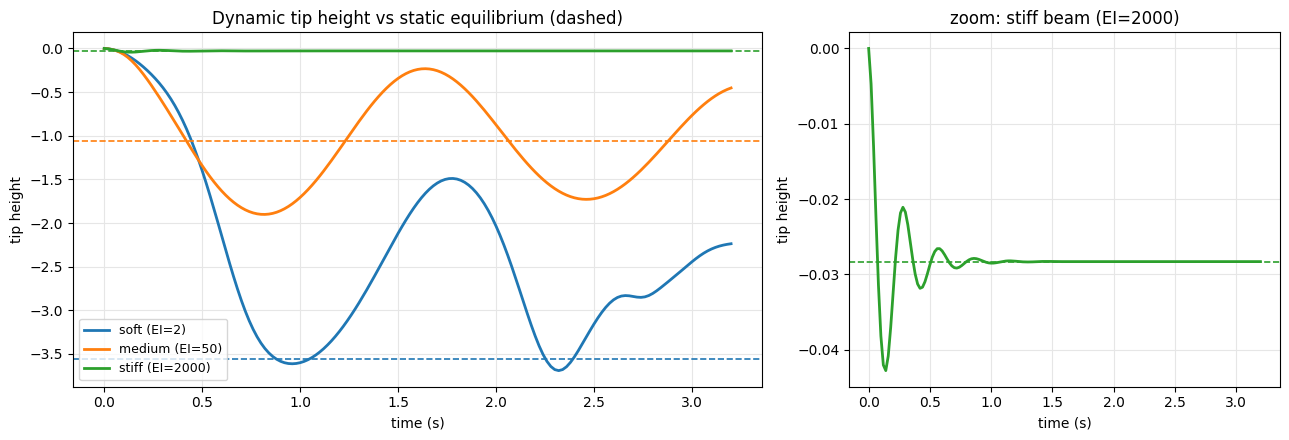

In [11]:
t_all = DT * np.arange(N_STEPS + 1)
colors = {name: plt.get_cmap("tab10")(j) for j, name in enumerate(EI_DYNAMIC)}
tip_static = {name: solve_static(EI)[0][-1, 1] for name, EI in EI_DYNAMIC.items()}
stiffest = max(EI_DYNAMIC, key=EI_DYNAMIC.get)
fig, (ax, ax_zoom) = plt.subplots(1, 2, figsize=(13, 4.5), gridspec_kw={"width_ratios": [1.6, 1]})
for name, EI in EI_DYNAMIC.items():
    ax.plot(t_all, runs[name][3], lw=2, color=colors[name], label=f"{name} (EI={EI:g})")
    ax.axhline(tip_static[name], color=colors[name], ls="--", lw=1.2)
ax_zoom.plot(t_all, runs[stiffest][3], lw=2, color=colors[stiffest])
ax_zoom.axhline(tip_static[stiffest], color=colors[stiffest], ls="--", lw=1.2)
ax.set(xlabel="time (s)", ylabel="tip height", title="Dynamic tip height vs static equilibrium (dashed)")
ax_zoom.set(xlabel="time (s)", ylabel="tip height", title=f"zoom: {stiffest} beam (EI={EI_DYNAMIC[stiffest]:g})")
ax.grid(True, color="0.9"); ax_zoom.grid(True, color="0.9"); ax.legend(fontsize=9)
fig.tight_layout()
simkit.filesystem.save_figure(fig, os.path.join(RESULTS_DIR, "tip_vs_time.png"),
                              copy_to=os.path.join(MEDIA_DIR, "014_tip_vs_time.png"))
plt.show()

The **static equilibria** over a wider sweep tell the same story: the droop shrinks steadily as the bending
stiffness increases.

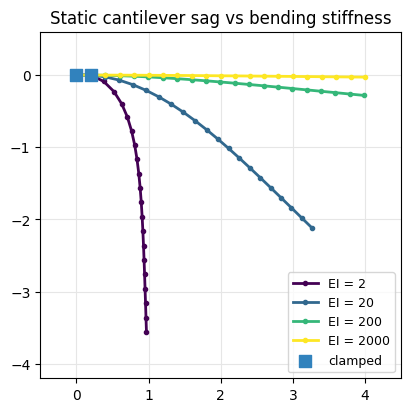

In [12]:
fig, ax = plt.subplots(figsize=(7.5, 4.5))
utils.setup_axes(ax, (-0.5, L + 0.5), (-L - 0.2, 0.6), title="Static cantilever sag vs bending stiffness")
cmap = plt.get_cmap("viridis")
for j, EI in enumerate(EI_STATIC):
    U = solve_static(EI)[0]
    ax.plot(U[:, 0], U[:, 1], "-o", ms=3, lw=2, color=cmap(j / (len(EI_STATIC) - 1)), label=f"EI = {EI:g}")
ax.scatter(X[pin_idx, 0], X[pin_idx, 1], s=70, marker="s", color=utils.PIN_C, zorder=5, label="clamped")
ax.legend(fontsize=9, loc="lower right")
simkit.filesystem.save_figure(fig, os.path.join(RESULTS_DIR, "static_sweep.png"),
                              copy_to=os.path.join(MEDIA_DIR, "014_static_sweep.png"))
plt.show()

## 4 &middot; Refine the mesh &rarr; convergence to one shape

Hold the *continuum* beam fixed ($L, EI, EA, \rho, g$) and change only the number of nodes `N`. Because the
stiffnesses and masses were scaled to be mesh-independent, the discrete equilibria pile up onto a **single
limiting curve**: coarse meshes are too stiff and under-droop (clamping two nodes also freezes the whole first
segment, $L/(N-1)$, visible as the flat root of N = 5), and each refinement moves less than the last.

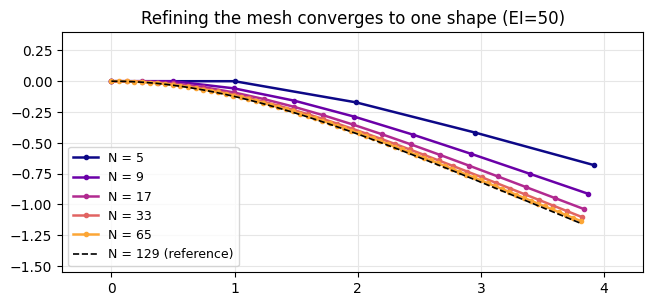

In [13]:
sols = {n_nodes: solve_static(EI_DEFAULT, n_nodes)[0] for n_nodes in N_REFINE + [N_REFERENCE]}
fig, ax = plt.subplots(figsize=(7.5, 4.5))
utils.setup_axes(ax, *utils.auto_limits(list(sols.values()), pad=0.4),
                 title=f"Refining the mesh converges to one shape (EI={EI_DEFAULT:g})")
cmap = plt.get_cmap("plasma")
for j, n_nodes in enumerate(N_REFINE):
    U = sols[n_nodes]
    ax.plot(U[:, 0], U[:, 1], "-o", ms=3, lw=1.8, color=cmap(j / len(N_REFINE)), label=f"N = {n_nodes}")
ax.plot(sols[N_REFERENCE][:, 0], sols[N_REFERENCE][:, 1], "k--", lw=1.2, label=f"N = {N_REFERENCE} (reference)")
ax.legend(fontsize=9, loc="lower left")
simkit.filesystem.save_figure(fig, os.path.join(RESULTS_DIR, "refinement.png"),
                              copy_to=os.path.join(MEDIA_DIR, "014_refinement.png"))
plt.show()

Measured against the finest mesh, the tip deflection error falls at first order: doubling the number of
segments roughly halves the error (the last point drops a bit faster because the N = 129 reference is itself
only approximate).

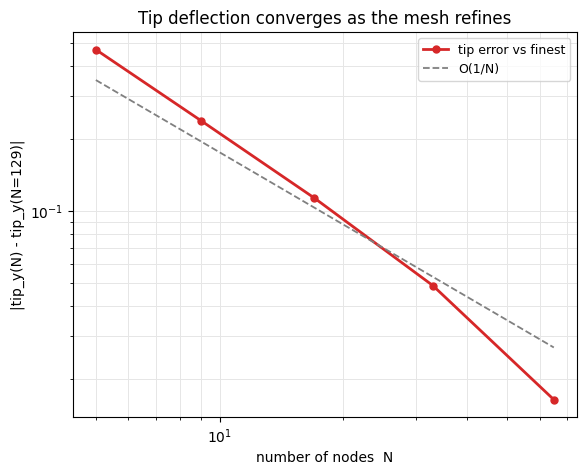

tip error: {5: 0.4697, 9: 0.238, 17: 0.1131, 33: 0.0489, 65: 0.0164}


In [14]:
tip_ref = sols[N_REFERENCE][-1, 1]
tip_err = [abs(sols[n_nodes][-1, 1] - tip_ref) for n_nodes in N_REFINE]
fig, ax = utils.loglog_plot(np.array(N_REFINE), {"tip error vs finest": tip_err},
                            xlabel="number of nodes  N", ylabel=f"|tip_y(N) - tip_y(N={N_REFERENCE})|",
                            colors={"tip error vs finest": "#d62728"}, ref_slopes={"O(1/N)": -1},
                            title="Tip deflection converges as the mesh refines")
simkit.filesystem.save_figure(fig, os.path.join(RESULTS_DIR, "tip_convergence.png"),
                              copy_to=os.path.join(MEDIA_DIR, "014_tip_convergence.png"))
plt.show()
print("tip error:", {n_nodes: round(float(err), 4) for n_nodes, err in zip(N_REFINE, tip_err)})

## 5 &middot; Aside: the same bending one dimension up

The hinge angle used here is the **2D** member of one family: discrete bending always lives on a
*codimension-1 hinge* shared by two flaps, and the energy $\tfrac12\kappa(\theta-\theta_0)^2$ is the same in
every dimension, only the geometry of $\theta$ changes. `simkit.dihedral_angles(X, C)` infers which one from
the data, and the same `bending_energy_x(x, C, theta0, kappa)` assembles both (the 3D
`discrete_shells_bending_*` functions are thin wrappers over it), so a bending **cloth** only swaps the
connectivity and adds a coordinate.

| | flaps | shared hinge | connectivity | angle |
|---|---|---|---|---|
| **curve in 2D** (this tutorial) | edges | a **vertex** | triple `(A,B,C)` | hinge turning angle |
| **surface in 3D** (cloth/shells) | triangles | an **edge** | quad `(x0,x1,x2,x3)` | dihedral fold angle |

### Takeaways
* Springs resist stretch; a **bending** energy on the hinge angles is what lets a beam resist *curvature* and
  hold a shape.
* Increasing bending stiffness $EI$ takes the cantilever from **floppy** (flops down under gravity) to
  **rigid** (holds nearly horizontal).
* Scaling the springs ($EA/\ell$), hinges ($EI/\ell$) and masses ($\rho\ell$) to a fixed continuum beam makes
  the simulation **mesh-independent**: refining `N` converges to one equilibrium at first order.
* The 2D hinge and 3D dihedral bending are the *same* energy one codimension apart, unified behind
  `simkit.dihedral_angles` / `bending_energy_x`.